Car Evaluation Database was derived from a simple hierarchical decision model originally developed for the demonstration of DEX, M. Bohanec, V. Rajkovic: Expert system for decision making. Sistemica 1(1), pp. 145-157, 1990.). The model evaluates cars according to the following concept structure:

CAR car acceptability . PRICE overall price . . buying buying price . . maint price of the maintenance . TECH technical characteristics . . COMFORT comfort . . . doors number of doors . . . persons capacity in terms of persons to carry . . . lug_boot the size of luggage boot . . safety estimated safety of the car

Input attributes are printed in lowercase. Besides the target concept (CAR), the model includes three intermediate concepts: PRICE, TECH, COMFORT. Every concept is in the original model related to its lower level descendants by a set of examples (for these examples sets see [Web Link]).

The Car Evaluation Database contains examples with the structural information removed, i.e., directly relates CAR to the six input attributes: buying, maint, doors, persons, lug_boot, safety.

Because of known underlying concept structure, this database may be particularly useful for testing constructive induction and structure discovery methods.

Attribute Information:

Class Values:

unacc, acc, good, vgood

Attributes:

buying: vhigh, high, med, low. maint: vhigh, high, med, low. doors: 2, 3, 4, 5more. persons: 2, 4, more. lug_boot: small, med, big. safety: low, med, high

#https://www.kaggle.com/datasets/elikplim/car-evaluation-data-set

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("13-car_evaluation.csv")
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [4]:
#Columns are not named properly so we rename them as follows
col_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
df.columns = col_names
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1727 non-null   str  
 1   maint     1727 non-null   str  
 2   doors     1727 non-null   str  
 3   persons   1727 non-null   str  
 4   lug_boot  1727 non-null   str  
 5   safety    1727 non-null   str  
 6   class     1727 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


In [6]:
for cols in df.columns:
    print(df[cols].value_counts(),"\n")

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64 

maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64 

doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64 

persons
4       576
more    576
2       575
Name: count, dtype: int64 

lug_boot
med      576
big      576
small    575
Name: count, dtype: int64 

safety
med     576
high    576
low     575
Name: count, dtype: int64 

class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64 



In [7]:
#class -> target variable
#doors, persons -> numeric variable
#rest -> categorical

In [8]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [9]:
df.isna().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [10]:
df["doors"].unique()

<StringArray>
['2', '3', '4', '5more']
Length: 4, dtype: str

In [11]:
df["doors"] = df["doors"].replace("5more","5")
df["doors"].unique()

<StringArray>
['2', '3', '4', '5']
Length: 4, dtype: str

In [12]:
df["doors"] = df["doors"].astype(int)

In [13]:
df["persons"].unique()

<StringArray>
['2', '4', 'more']
Length: 3, dtype: str

In [14]:
df["persons"] = df["persons"].replace("more","5")
df["persons"].unique()

<StringArray>
['2', '4', '5']
Length: 3, dtype: str

In [15]:
df["persons"] =df["persons"].astype(int)

<Axes: xlabel='buying', ylabel='maint'>

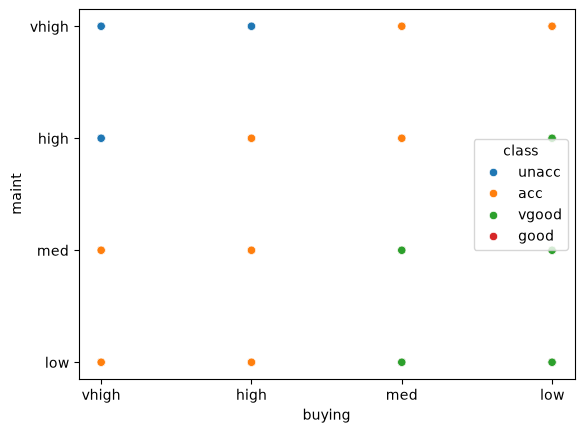

In [16]:
sns.scatterplot(x=df["buying"], y=df["maint"], hue=df["class"])

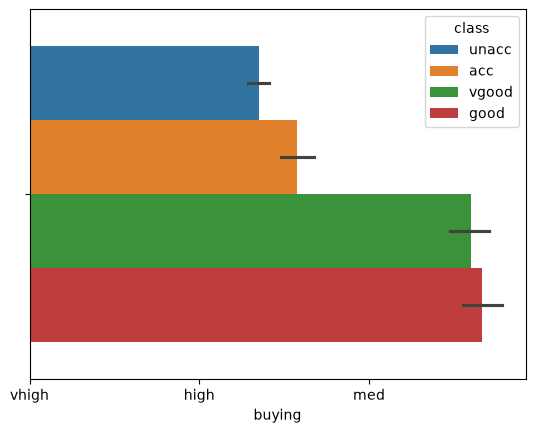

<Axes: xlabel='lug_boot', ylabel='safety'>

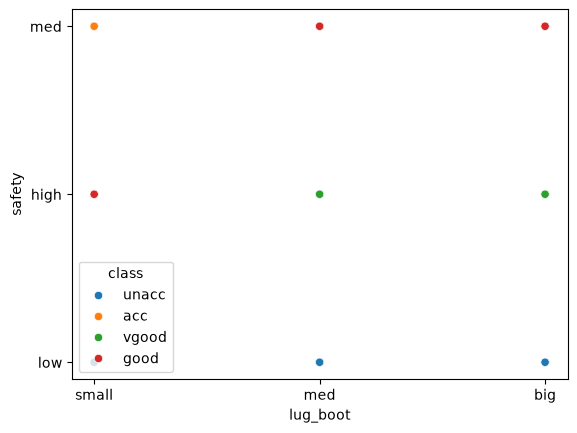

In [17]:
sns.barplot(x=df["buying"], hue=df["class"])
plt.show()
sns.scatterplot(x=df["lug_boot"], y=df["safety"], hue=df["class"])

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1727 non-null   str  
 1   maint     1727 non-null   str  
 2   doors     1727 non-null   int64
 3   persons   1727 non-null   int64
 4   lug_boot  1727 non-null   str  
 5   safety    1727 non-null   str  
 6   class     1727 non-null   str  
dtypes: int64(2), str(5)
memory usage: 94.6 KB


In [19]:
X = df.drop("class", axis=1)
y= df["class"]

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.3, random_state=15)
X_train.shape

(518, 6)

    ORDINAL ENCODING

In [21]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [22]:
categorical_cols = ["buying", "maint", "lug_boot", "safety"]
numerical_cols = ["doors", "persons"]

ordinal_encoder = OrdinalEncoder(
    categories=[
        ["low", "med", "high", "vhigh"], #buying col
        ["low", "med", "high", "vhigh"], #maint col
        ["small", "med", "big"], #lug_boot col
        ["low", "med", "high"], #safety col
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("transformation_name_doesnt_matter", ordinal_encoder, categorical_cols)
        #this feature could also be used with multipler encoder i.e:
        #("name_tranformation", one_hot_encoder, cols_list),
        #("name_tranformation", label_encoder, cols_list)
    ],
    remainder="passthrough" # DO NOT FORGET to set this so that it does not deletes not encoded columns
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [23]:
pd.DataFrame(X_train_transformed)

,0,1,2,3,4,5
0,2.0,1.0,1.0,0.0,3.0,5.0
1,1.0,0.0,2.0,2.0,3.0,2.0
2,0.0,2.0,1.0,0.0,5.0,5.0
3,2.0,0.0,2.0,2.0,2.0,5.0
4,1.0,2.0,0.0,1.0,4.0,2.0
...,...,...,...,...,...,...
513,2.0,1.0,0.0,2.0,2.0,5.0
514,3.0,2.0,1.0,1.0,3.0,5.0
515,3.0,0.0,2.0,1.0,4.0,2.0
516,2.0,2.0,2.0,1.0,5.0,5.0


DECISION TREE

In [24]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=0)

tree_model.fit(X_train_transformed, y_train)

y_pred = tree_model.predict(X_test_transformed)

In [25]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7923904052936311
[[144   0 128   0]
 [ 48   0   0   0]
 [ 31   0 814   0]
 [ 44   0   0   0]]
              precision    recall  f1-score   support

         acc       0.54      0.53      0.53       272
        good       0.00      0.00      0.00        48
       unacc       0.86      0.96      0.91       845
       vgood       0.00      0.00      0.00        44

    accuracy                           0.79      1209
   macro avg       0.35      0.37      0.36      1209
weighted avg       0.73      0.79      0.76      1209



c:\Users\umuty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\umuty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\umuty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

[Text(0.3333333333333333, 0.875, 'safety <= 0.5\ngini = 0.456\nsamples = 518\nvalue = [112, 21, 364, 21]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 174\nvalue = [0, 0, 174, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'persons <= 3.0\ngini = 0.581\nsamples = 344\nvalue = [112.0, 21.0, 190.0, 21.0]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 114\nvalue = [0, 0, 114, 0]'),
 Text(0.6666666666666666, 0.375, 'buying <= 1.5\ngini = 0.637\nsamples = 230\nvalue = [112, 21, 76, 21]'),
 Text(0.5, 0.125, 'gini = 0.656\nsamples = 117\nvalue = [60.0, 21.0, 15.0, 21.0]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.497\nsamples = 113\nvalue = [52.0, 0.0, 61.0, 0.0]')]

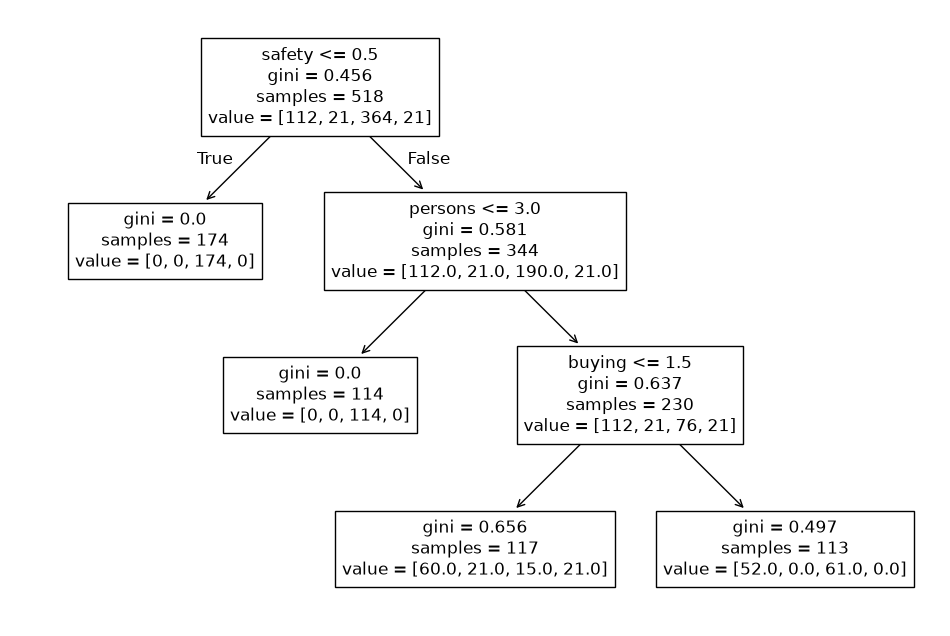

In [26]:
plt.figure(figsize=(12,8))

from sklearn import tree

column_names = categorical_cols + numerical_cols

tree.plot_tree(tree_model.fit(X_train_transformed, y_train), feature_names=column_names)

    HYPERPARAMETER TUNING

In [27]:
param = {
    "criterion" :   ["gini", "entropy", "log_loss"],
    "splitter"  :   ["best", "random"],
    "max_depth" :   [1,2,3,4,5,15,None],
    "max_features" :   ["sqrt", "log2", None]
}

from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid= param, cv=5, scoring="accuracy")

In [28]:
grid.fit(X_train_transformed, y_train)

grid.best_params_

{'criterion': 'log_loss',
 'max_depth': None,
 'max_features': None,
 'splitter': 'best'}

In [29]:
y_pred = grid.predict(X_test_transformed)

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9536807278742763
[[250   3  19   0]
 [ 11  36   1   0]
 [ 15   2 828   0]
 [  5   0   0  39]]
              precision    recall  f1-score   support

         acc       0.89      0.92      0.90       272
        good       0.88      0.75      0.81        48
       unacc       0.98      0.98      0.98       845
       vgood       1.00      0.89      0.94        44

    accuracy                           0.95      1209
   macro avg       0.94      0.88      0.91      1209
weighted avg       0.95      0.95      0.95      1209



In [30]:
#OBSERVE TREE MODEL WITH BEST_PARAMS_
#NOTICE: no random_state assigned inside the estimator(DecisionTreeClassifier), thus best_params_ output differs in every execution
new_tree_model = DecisionTreeClassifier(criterion="gini", max_depth= None, max_features=None, splitter="best")

new_tree_model.fit(X_train_transformed, y_train)
y_pred = new_tree_model.predict(X_test_transformed)

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9520264681555004
[[240   2  30   0]
 [  9  38   1   0]
 [  9   2 834   0]
 [  5   0   0  39]]
              precision    recall  f1-score   support

         acc       0.91      0.88      0.90       272
        good       0.90      0.79      0.84        48
       unacc       0.96      0.99      0.98       845
       vgood       1.00      0.89      0.94        44

    accuracy                           0.95      1209
   macro avg       0.95      0.89      0.91      1209
weighted avg       0.95      0.95      0.95      1209



[Text(0.5806451612903226, 0.9583333333333334, 'safety <= 0.5\ngini = 0.456\nsamples = 518\nvalue = [112, 21, 364, 21]'),
 Text(0.5645161290322581, 0.875, 'gini = 0.0\nsamples = 174\nvalue = [0, 0, 174, 0]'),
 Text(0.5725806451612904, 0.9166666666666667, 'True  '),
 Text(0.5967741935483871, 0.875, 'persons <= 3.0\ngini = 0.581\nsamples = 344\nvalue = [112.0, 21.0, 190.0, 21.0]'),
 Text(0.5887096774193549, 0.9166666666666667, '  False'),
 Text(0.5806451612903226, 0.7916666666666666, 'gini = 0.0\nsamples = 114\nvalue = [0, 0, 114, 0]'),
 Text(0.6129032258064516, 0.7916666666666666, 'buying <= 1.5\ngini = 0.637\nsamples = 230\nvalue = [112, 21, 76, 21]'),
 Text(0.3548387096774194, 0.7083333333333334, 'maint <= 1.5\ngini = 0.656\nsamples = 117\nvalue = [60.0, 21.0, 15.0, 21.0]'),
 Text(0.16129032258064516, 0.625, 'safety <= 1.5\ngini = 0.684\nsamples = 55\nvalue = [16, 21, 2, 16]'),
 Text(0.07258064516129033, 0.5416666666666666, 'lug_boot <= 0.5\ngini = 0.531\nsamples = 24\nvalue = [13, 10,

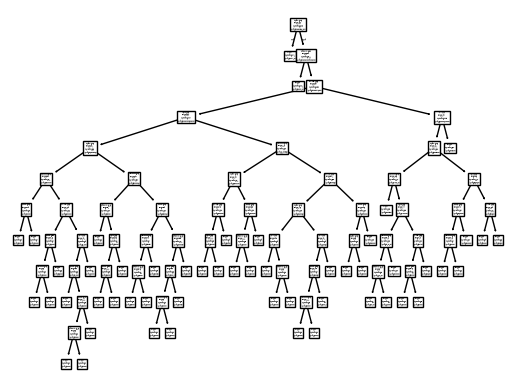

In [31]:
tree.plot_tree(new_tree_model.fit(X_train_transformed, y_train), feature_names= column_names)

    PRUNING

In [52]:
df_new = pd.read_csv("11-iris.csv")
df_new.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [53]:
X = df_new.drop(["Id", "Species"], axis=1)
y = df_new["Species"]


In [54]:

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.2, random_state=10)


In [55]:

tree_model = DecisionTreeClassifier()


In [56]:
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

[Text(0.6, 0.8333333333333334, 'PetalWidthCm <= 1.75\ngini = 0.66\nsamples = 30\nvalue = [9, 9, 12]'),
 Text(0.4, 0.5, 'PetalWidthCm <= 0.7\ngini = 0.5\nsamples = 18\nvalue = [9, 9, 0]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [9, 0, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [0, 9, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 12\nvalue = [0, 0, 12]'),
 Text(0.7, 0.6666666666666667, '  False')]

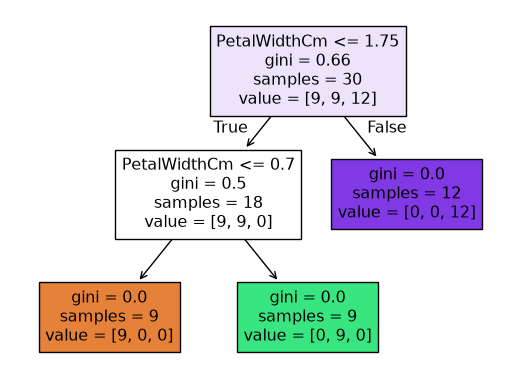

In [57]:
tree.plot_tree(tree_model.fit(X_train, y_train), feature_names= X_train.columns, filled=True)

In [58]:
y_pred = tree_model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.95
[[41  0  0]
 [ 0 40  1]
 [ 0  5 33]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        41
Iris-versicolor       0.89      0.98      0.93        41
 Iris-virginica       0.97      0.87      0.92        38

       accuracy                           0.95       120
      macro avg       0.95      0.95      0.95       120
   weighted avg       0.95      0.95      0.95       120



In [59]:
tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.95
[[41  0  0]
 [ 0 40  1]
 [ 0  5 33]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        41
Iris-versicolor       0.89      0.98      0.93        41
 Iris-virginica       0.97      0.87      0.92        38

       accuracy                           0.95       120
      macro avg       0.95      0.95      0.95       120
   weighted avg       0.95      0.95      0.95       120



[Text(0.6, 0.8333333333333334, 'PetalWidthCm <= 1.75\ngini = 0.66\nsamples = 30\nvalue = [9, 9, 12]'),
 Text(0.4, 0.5, 'PetalLengthCm <= 2.6\ngini = 0.5\nsamples = 18\nvalue = [9, 9, 0]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [9, 0, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [0, 9, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 12\nvalue = [0, 0, 12]'),
 Text(0.7, 0.6666666666666667, '  False')]

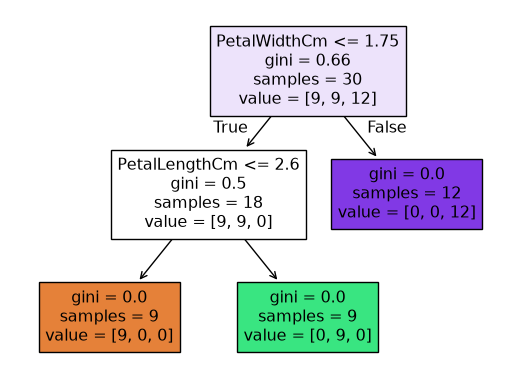

In [60]:
tree.plot_tree(tree_model.fit(X_train, y_train),feature_names=X_train.columns, filled=True)